<a href="https://colab.research.google.com/github/KleberAr4uj0/a3-Joberto/blob/main/A3_Joberto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dataset spotify kaggle


# 🎵 Sistema de Recomendação Musical - Spotify

**Algoritmos:** K-Means Clustering + PCA + Cosine Similarity  
**Dataset:** [Spotify Tracks Dataset - Kaggle](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

---

### Como usar este notebook
Execute os blocos **na ordem**. Cada bloco é uma fase independente do pipeline:

| Bloco | Fase |
|-------|------|
| 1 | Instalação e importações |
| 2 | Upload e leitura do dataset |
| 3 | Pré-processamento |
| 4 | EDA - Análise exploratória |
| 5 | Normalização |
| 6 | Método do Cotovelo + Silhouette |
| 7 | PCA - Redução de dimensionalidade |
| 8 | K-Means - Treinamento |
| 9 | Avaliação do modelo |
| 10 | Visualização dos clusters |
| 11 | Sistema de recomendação (Cosine Similarity) |

## Comparação de Algoritmos de Clustering

### K-Means
**Vantagens:**
- Rápido e escalável - funciona bem com 50.000 músicas
- Resultado reprodutível com random_state fixo
- Fácil de tunar via método do cotovelo

**Desvantagens:**
- Exige definir k previamente
- Assume clusters esféricos e de tamanho similar
- Sensível a outliers

---

### DBSCAN
**Vantagens:**
- Não precisa definir k - descobre o número de clusters sozinho
- Detecta clusters de formato arbitrário
- Trata outliers como ruído automaticamente

**Desvantagens:**
- Muito lento com datasets grandes (50k+ linhas)
- Difícil de tunar (parâmetros epsilon e min_samples)
- Com dados de alta dimensão (9 features) perde eficácia
  - fenômeno conhecido como "maldição da dimensionalidade"

---

### Por que K-Means é mais adequado aqui?

Dados musicais têm volume alto, dimensionalidade média (9 features)
e clusters naturalmente esféricos no espaço de features de áudio.
O K-Means lida bem com esse perfil, é rápido o suficiente para
rodar no Colab e produz grupos interpretáveis.

O DBSCAN seria inviável neste contexto: com 50.000 músicas e
9 dimensões, o cálculo de vizinhança se tornaria extremamente
lento, e a escolha do epsilon (raio de vizinhança) seria
praticamente impossível de acertar sem muita experimentação.

## Bloco 1 - Instalação e Importações

In [ ]:
# Instalar bibliotecas extras caso necessário
# O Colab já vem com sklearn, pandas, matplotlib e numpy
!pip install -q joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity  # ← trocado de euclidean
from google.colab import files

print('✅ Importações concluídas')

✅ Importações concluídas


## Bloco 2 - Upload e Leitura do Dataset

Baixe o arquivo `spotify_tracks.csv` do Kaggle e faça o upload abaixo.  
**Link:** https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

In [ ]:
# Faz o upload do arquivo CSV para o Colab
uploaded = files.upload()

# Lê o arquivo enviado
nome_arquivo = list(uploaded.keys())[0]
df_raw = pd.read_csv(nome_arquivo)

print(f'✅ Dataset carregado: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')
print(f'   Colunas: {list(df_raw.columns)}')
df_raw.head(3)

Saving dataset.csv to dataset (5).csv
✅ Dataset carregado: 114,000 linhas × 21 colunas
   Colunas: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## Bloco 3 - Pré-processamento

Etapas executadas nesta fase:

1. **Remoção de colunas irrelevantes** - `track_id` e `Unnamed: 0` são identificadores que não contribuem para a similaridade musical.
2. **Remoção de valores nulos** - linhas incompletas corrompem a normalização e os centroides do K-Means.
3. **Remoção de duplicatas** - músicas com mesmo nome e artista distorcem os clusters e as recomendações.
4. **Remoção de outliers via percentil (1%–99%) - mantém 98% da distribuição removendo apenas valores extremos** - valores extremos em `loudness` e `tempo` puxam os centroides para fora da distribuição real.
5. **Amostragem aleatória reprodutível** - 50 000 registros para equilibrar representatividade e performance.

In [ ]:
# ── Configurações globais ──────────────────────────────────────
SAMPLE_SIZE  = 50_000
RANDOM_STATE = 42
N_CLUSTERS   = 10  # ajuste após analisar o gráfico do Bloco 6
ELBOW_RANGE  = range(2, 21)

FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'valence', 'tempo', 'popularity'
]

# ── Pré-processamento ─────────────────────────────────────────
df = df_raw.copy()

# 1. Remover colunas de identificação
cols_drop = [c for c in ['track_id', 'Unnamed: 0'] if c in df.columns]
df = df.drop(columns=cols_drop)
print(f'  Colunas removidas: {cols_drop}')

# 2. Remover nulos
antes = len(df)
df = df.dropna().reset_index(drop=True)
print(f'  Nulos removidos: {antes - len(df)} linhas')

# 3. Remover duplicatas (mesmo nome + artista)
antes = len(df)
df = df.drop_duplicates(subset=['track_name', 'artists']).reset_index(drop=True)
print(f'  Duplicatas removidas: {antes - len(df)} linhas')

# Remover outliers via percentil (1% – 99%)
# Mantém 98% da distribuição, removendo apenas valores extremos
antes = len(df)
for col in FEATURES:
    Q1 = df[col].quantile(0.01)
    Q3 = df[col].quantile(0.99)
    df = df[(df[col] >= Q1) & (df[col] <= Q3)]
df = df.reset_index(drop=True)
print(f'  Outliers removidos: {antes - len(df)} linhas')

# 5. Amostragem
n = min(SAMPLE_SIZE, len(df))
df = df.sample(n, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'\n✅ Dataset final: {len(df):,} músicas | {df["track_genre"].nunique()} gêneros')
df.head(3)

  Colunas removidas: ['track_id', 'Unnamed: 0']
  Nulos removidos: 1 linhas
  Duplicatas removidas: 32656 linhas
  Outliers removidos: 11798 linhas

✅ Dataset final: 50,000 músicas | 113 gêneros


,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Netsky;Macklemore;Digital Farm Animals,Rio (feat. Macklemore & Digital Farm Animals) ...,Rio (feat. Macklemore & Digital Farm Animals) ...,47,205320,True,0.614,0.920,0,-5.187,1,0.0532,0.01140,0.000018,0.0987,0.158,86.542,4,drum-and-bass
1,Giuseppe Verdi;Riccardo Muti;New Philharmonia ...,Verdi: Aida,"Verdi: Aida, Act 2: ""Ebben, qual nuovo fremito...",21,175066,False,0.356,0.128,5,-15.501,1,0.0473,0.98900,0.000000,0.1280,0.103,79.638,3,opera
2,The Hillbilly Moon Explosion;Mark Philips,With Monsters and Gods,Jackson,29,185933,False,0.572,0.863,5,-5.265,0,0.0465,0.00487,0.000243,0.2480,0.811,141.999,4,psych-rock


### Por que essas 9 features foram escolhidas?

O dataset possui colunas de dois tipos:
- **Identificadores:** `track_id`, `track_name` e `artists` - servem apenas
  para identificar as músicas e não representam características sonoras
- **Features de áudio:** fornecidas pela API do Spotify, descrevem
  propriedades acústicas e perceptuais das músicas

As 9 features escolhidas foram:

| Feature | O que representa |
|---------|-----------------|
| danceability | Adequação para dançar |
| energy | Intensidade e atividade |
| loudness | Volume médio em dB |
| speechiness | Presença de palavras faladas |
| acousticness | Probabilidade de ser acústica |
| instrumentalness | Ausência de vocais |
| valence | Positividade emocional |
| tempo | BPM — velocidade da música |
| popularity | Popularidade da música na plataforma |

Essas variáveis representam características diretamente relacionadas à
experiência auditiva e permitem agrupar músicas com perfis sonoros semelhantes.

Variáveis como `key`, `mode` e `duration_ms` foram excluídas por
representarem propriedades técnicas que possuem menor influência
na percepção geral de similaridade musical quando comparadas às
características acústicas principais.

## Bloco 4 - EDA: Análise Exploratória

Entender a distribuição de cada feature antes de modelar evita surpresas nos clusters.  
Distribuições muito assimétricas ou bimodais podem indicar necessidade de transformações adicionais.

=== RESUMO ESTATÍSTICO ===


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo,popularity
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,0.575,0.650,-7.970,0.080,0.309,0.152,0.481,123.191,34.956
std,0.160,0.237,3.948,0.084,0.323,0.300,0.252,27.686,18.941
min,0.120,0.031,-25.141,0.026,0.000,0.000,0.038,69.082,0.000
25%,0.469,0.479,-9.924,0.036,0.015,0.000,0.270,100.117,21.000
50%,0.584,0.685,-7.107,0.048,0.174,0.000,0.471,123.074,36.000
75%,0.695,0.853,-5.137,0.083,0.581,0.051,0.685,140.228,49.000
max,0.903,0.993,-1.663,0.826,0.989,0.947,0.965,192.492,78.000


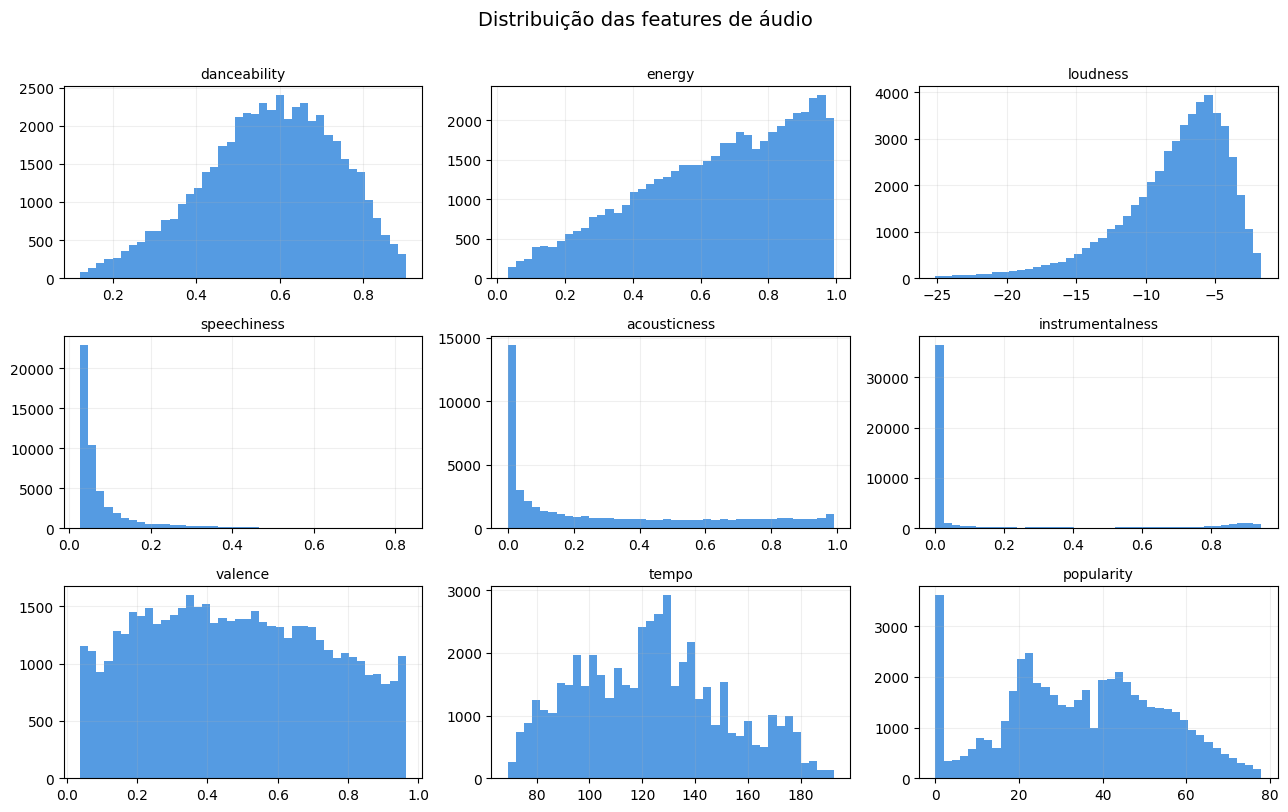

✅ Histogramas exibidos


In [ ]:
# Resumo estatístico
print('=== RESUMO ESTATÍSTICO ===')
display(df[FEATURES].describe().round(3))

# Histogramas de todas as features
fig, axes = plt.subplots(3, 3, figsize=(13, 8))
fig.suptitle('Distribuição das features de áudio', fontsize=14, y=1.01)

for ax, col in zip(axes.flatten(), FEATURES):
    ax.hist(df[col], bins=40, color='#378ADD', edgecolor='none', alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('eda_features.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Histogramas exibidos')

## Bloco 5 - Normalização (StandardScaler)

O K-Means usa distância para agrupar pontos. Sem normalização, features de maior escala dominam o cálculo:
- `loudness` varia de **−60 a 0 dB**
- `danceability` varia de **0 a 1**

O `StandardScaler` transforma cada feature para **média = 0** e **desvio padrão = 1**, colocando todas na mesma escala.

In [ ]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])

print(f'✅ Normalização concluída')
print(f'   Shape: {X_scaled.shape}  →  {X_scaled.shape[0]:,} músicas × {X_scaled.shape[1]} features')
print(f'   Média (deve ser ≈0): {X_scaled.mean(axis=0).round(4)}')
print(f'   Desvio (deve ser ≈1): {X_scaled.std(axis=0).round(4)}')

✅ Normalização concluída
   Shape: (50000, 9)  →  50,000 músicas × 9 features
   Média (deve ser ≈0): [ 0.  0. -0. -0. -0. -0.  0. -0.  0.]
   Desvio (deve ser ≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Bloco 6 - Método do Cotovelo + Silhouette Score

Para escolher o número ideal de clusters **k** usamos dois critérios em paralelo:

- **Inércia (cotovelo):** soma das distâncias quadradas de cada ponto ao seu centroide. Diminui à medida que k aumenta — o "cotovelo" indica onde o ganho marginal cai.
- **Silhouette Score:** mede coesão interna e separação entre clusters. Varia de −1 a 1; quanto maior, melhor.

> ⚠️ **Após ver os gráficos**, atualize a constante `N_CLUSTERS` no Bloco 3 antes de continuar.

Calculando cotovelo (k = 2 a 20)... pode levar alguns minutos.
  k= 2 | inércia=     359,893 | silhouette=0.2154
  k= 3 | inércia=     320,473 | silhouette=0.1502
  k= 4 | inércia=     291,183 | silhouette=0.1563
  k= 5 | inércia=     263,011 | silhouette=0.1636
  k= 6 | inércia=     244,857 | silhouette=0.1660
  k= 7 | inércia=     230,933 | silhouette=0.1555
  k= 8 | inércia=     221,454 | silhouette=0.1478
  k= 9 | inércia=     212,751 | silhouette=0.1420
  k=10 | inércia=     205,277 | silhouette=0.1393
  k=11 | inércia=     199,168 | silhouette=0.1395
  k=12 | inércia=     193,311 | silhouette=0.1386
  k=13 | inércia=     188,359 | silhouette=0.1393
  k=14 | inércia=     183,770 | silhouette=0.1380
  k=15 | inércia=     179,802 | silhouette=0.1345
  k=16 | inércia=     176,271 | silhouette=0.1332
  k=17 | inércia=     173,125 | silhouette=0.1328
  k=18 | inércia=     169,979 | silhouette=0.1358
  k=19 | inércia=     166,561 | silhouette=0.1328
  k=20 | inércia=     163,447 | silho

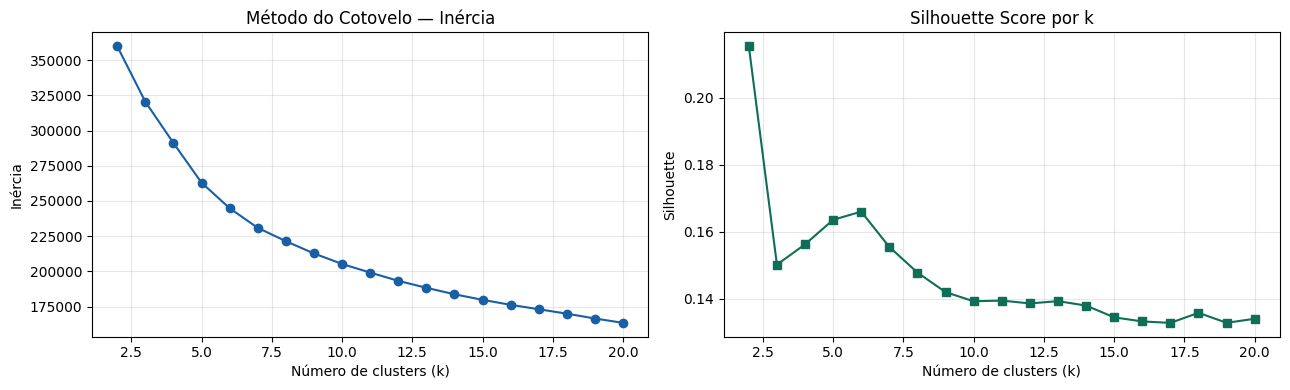


✅ k com maior Silhouette Score: 2
   → Atualize N_CLUSTERS=2 no Bloco 3 se quiser usar este valor.


In [ ]:
print('Calculando cotovelo (k = 2 a 20)... pode levar alguns minutos.')

inertias, silhouettes = [], []

for k in ELBOW_RANGE:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_tmp = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels_tmp,
                           sample_size=5000, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'  k={k:2d} | inércia={km.inertia_:>12,.0f} | silhouette={sil:.4f}')

# Gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ELBOW_RANGE, inertias, marker='o', color='#185FA5')
ax1.set_title('Método do Cotovelo — Inércia')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inércia')
ax1.grid(alpha=0.3)

ax2.plot(ELBOW_RANGE, silhouettes, marker='s', color='#0F6E56')
ax2.set_title('Silhouette Score por k')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cotovelo_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

melhor_k = list(ELBOW_RANGE)[silhouettes.index(max(silhouettes))]
print(f'\n✅ k com maior Silhouette Score: {melhor_k}')
print(f'   → Atualize N_CLUSTERS={melhor_k} no Bloco 3 se quiser usar este valor.')

## Bloco 7 - PCA: Redução de Dimensionalidade

O PCA (Principal Component Analysis) projeta as 9 features originais em componentes ortogonais ordenados por variância explicada.

**Uso aqui:**
- 2 componentes → visualização 2D dos clusters
- Gráfico de variância acumulada → diagnóstico de quantos componentes seriam necessários para preservar 90% da informação

> O clustering é feito no espaço original de 9 features (não no PCA), para não perder informação. O PCA é apenas para visualização.

Variância explicada → PC1: 28.9%  |  PC2: 16.2%  |  Total: 45.1%


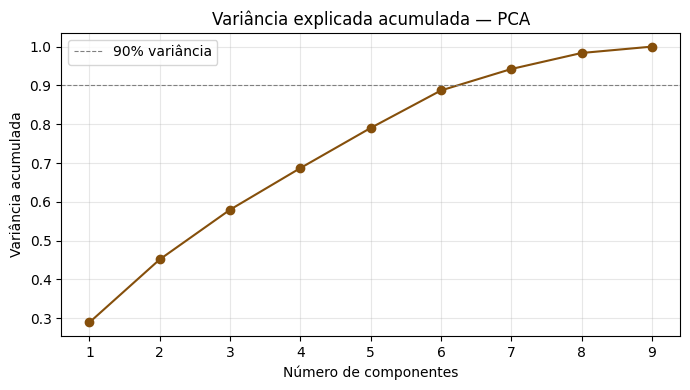

✅ PCA concluído


In [ ]:
# PCA com 2 componentes para visualização
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

var = pca.explained_variance_ratio_
print(f'Variância explicada → PC1: {var[0]:.1%}  |  PC2: {var[1]:.1%}  |  Total: {sum(var):.1%}')

# Gráfico de variância acumulada (diagnóstico)
pca_full = PCA().fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='#854F0B')
plt.axhline(0.90, color='gray', linestyle='--', linewidth=0.8, label='90% variância')
plt.title('Variância explicada acumulada — PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Variância acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variancia.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ PCA concluído')

## Bloco 8 - K-Means: Treinamento do Modelo

O K-Means agrupa as músicas em **k clusters** minimizando a inércia (soma das distâncias quadradas ao centroide).  
O modelo é salvo com `joblib` para evitar re-treinar em execuções futuras.

> Lembre de ajustar `N_CLUSTERS` no Bloco 3 conforme o gráfico do Bloco 6.

In [ ]:
MODEL_PATH  = 'kmeans_model.joblib'
SCALER_PATH = 'scaler.joblib'

# Remover modelo salvo para forçar novo treino
import os
if os.path.exists(MODEL_PATH):
    os.remove(MODEL_PATH)
if os.path.exists(SCALER_PATH):
    os.remove(SCALER_PATH)

if os.path.exists(MODEL_PATH):
    print('Modelo salvo encontrado — carregando...')
    km     = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    labels = km.predict(X_scaled)
else:
    print(f'Treinando K-Means com k={N_CLUSTERS}...')
    km     = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    joblib.dump(km,     MODEL_PATH)
    joblib.dump(scaler, SCALER_PATH)
    print('   Modelo salvo em disco')

df['cluster'] = labels

print(f'\n✅ Treinamento concluído')
print(f'   Inércia final: {km.inertia_:,.0f}')
print(f'   Distribuição dos clusters:')
print(df['cluster'].value_counts().sort_index().to_string())

Treinando K-Means com k=10...
   Modelo salvo em disco

✅ Treinamento concluído
   Inércia final: 205,277
   Distribuição dos clusters:
cluster
0    5141
1    5437
2    6641
3    5358
4    2448
5    3982
6    3098
7    6391
8    6266
9    5238


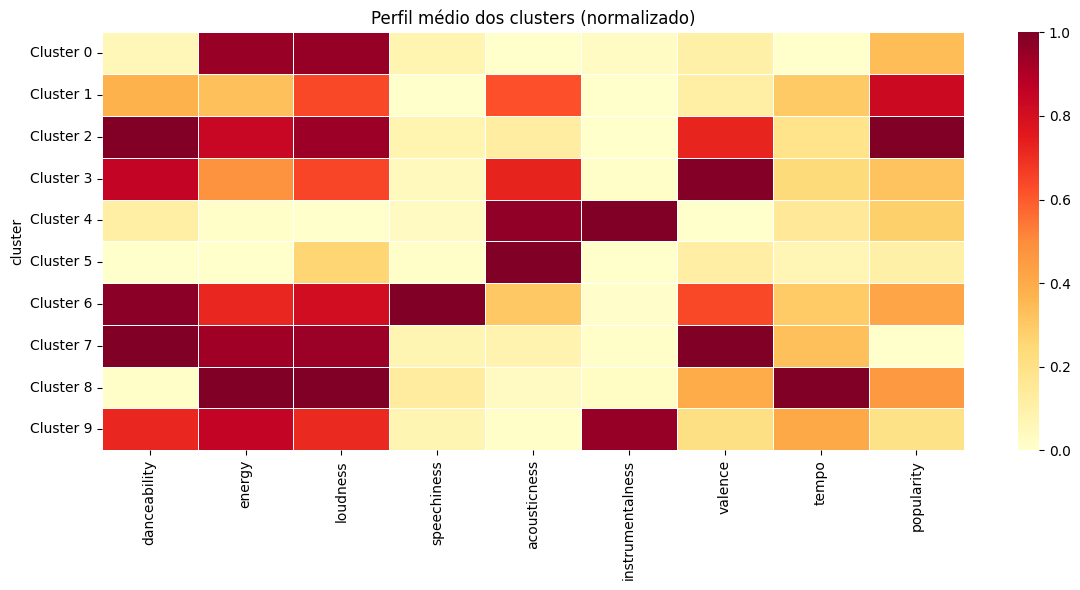


Característica dominante por cluster:
  Cluster  0 → loudness (-5.814)
  Cluster  1 → popularity (49.687)
  Cluster  2 → popularity (55.975)
  Cluster  3 → valence (0.722)
  Cluster  4 → instrumentalness (0.832)
  Cluster  5 → acousticness (0.807)
  Cluster  6 → speechiness (0.341)
  Cluster  7 → danceability (0.683)
  Cluster  8 → energy (0.836)
  Cluster  9 → instrumentalness (0.792)


In [ ]:
# Perfil médio de cada cluster
perfil = df.groupby('cluster')[FEATURES].mean().round(3)

# Normalizar para comparação visual (0 a 1)
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

# Heatmap dos clusters
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(perfil_norm, annot=False, cmap='YlOrRd',
            linewidths=0.5, yticklabels=[f'Cluster {i}' for i in perfil.index])
plt.title('Perfil médio dos clusters (normalizado)')
plt.tight_layout()
plt.show()

# Nomear clusters automaticamente pelo atributo dominante
print("\nCaracterística dominante por cluster:")
for cluster_id, row in perfil_norm.iterrows():
    dominante = row.idxmax()
    print(f"  Cluster {cluster_id:2d} → {dominante} ({perfil.loc[cluster_id, dominante]:.3f})")

## Bloco 9 - Avaliação do Modelo

Métricas utilizadas:

| Métrica | Interpretação | Faixa |
|---------|--------------|-------|
| **Silhouette Score** | Mede coesão interna e separação entre clusters | −1 a 1 (maior = melhor) |
| **Davies-Bouldin Score** | Relação entre dispersão interna e separação entre clusters | ≥ 0 (menor = melhor) |

## Interpretação das métricas

**Silhouette Score**
Valores próximos de 0.1~0.2 são esperados em dados musicais —
as fronteiras entre gêneros e estilos são naturalmente difusas,
não há separação rígida como em outros domínios.
Um valor negativo num cluster indica que aquelas músicas estão
mais próximas de outro cluster do que do próprio.

**Davies-Bouldin Score**
Valores abaixo de 2.0 indicam boa separação relativa entre clusters.
Quanto mais próximo de 0, mais compactos e separados são os grupos.

**O que esses valores dizem sobre música?**
Dados musicais são intrinsecamente sobrepostos — uma música pop
pode ter características de rock, uma eletrônica pode ser acústica.
Por isso métricas de clustering nunca serão altas neste domínio,
e isso é esperado, não um problema do modelo.

In [ ]:
sil_score = silhouette_score(X_scaled, labels,
                              sample_size=10_000, random_state=RANDOM_STATE)
db_score  = davies_bouldin_score(X_scaled, labels)

print('=== MÉTRICAS DE AVALIAÇÃO ===')
print(f'  Silhouette Score : {sil_score:.4f}   (−1 a 1, maior = melhor)')
print(f'  Davies-Bouldin   : {db_score:.4f}   (≥0, menor = melhor)')
print(f'  Inércia final    : {km.inertia_:,.0f}')

# Silhouette por cluster — identifica clusters mal formados
from sklearn.metrics import silhouette_samples
sil_vals = silhouette_samples(X_scaled, labels)

print('\n  Silhouette médio por cluster:')
for c in sorted(np.unique(labels)):
    media = sil_vals[labels == c].mean()
    barra = '█' * int(media * 40)
    print(f'  Cluster {c:2d}: {media:+.4f}  {barra}')

=== MÉTRICAS DE AVALIAÇÃO ===
  Silhouette Score : 0.1392   (−1 a 1, maior = melhor)
  Davies-Bouldin   : 1.6470   (≥0, menor = melhor)
  Inércia final    : 205,277

  Silhouette médio por cluster:
  Cluster  0: +0.1375  █████
  Cluster  1: +0.1258  █████
  Cluster  2: +0.1636  ██████
  Cluster  3: +0.0948  ███
  Cluster  4: +0.1659  ██████
  Cluster  5: +0.1371  █████
  Cluster  6: +0.1225  ████
  Cluster  7: +0.1620  ██████
  Cluster  8: +0.1355  █████
  Cluster  9: +0.1545  ██████


## Bloco 10 - Visualização dos Clusters (PCA 2D)

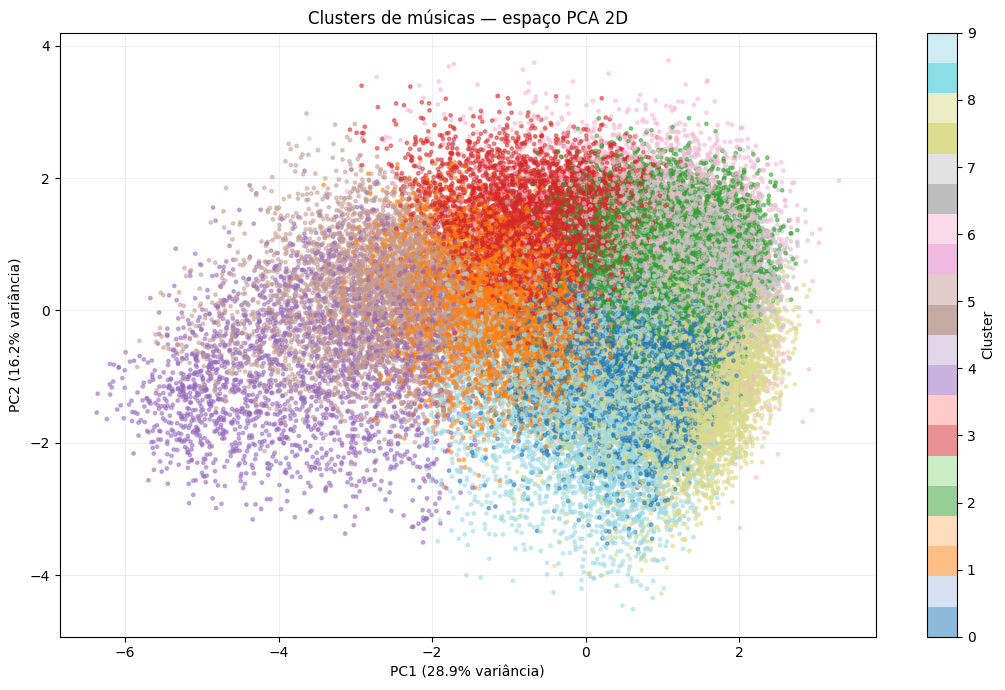

✅ Visualização salva em clusters_pca.png


In [ ]:
plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels, cmap='tab20',
    s=6, alpha=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.title('Clusters de músicas — espaço PCA 2D')
plt.xlabel(f'PC1 ({var[0]:.1%} variância)')
plt.ylabel(f'PC2 ({var[1]:.1%} variância)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualização salva em clusters_pca.png')

## Como a aplicação seleciona as músicas

O mecanismo de seleção funciona em 3 etapas:

**Etapa 1 - Agrupamento com K-Means**
Todas as 50.000 músicas são agrupadas em k clusters com base
nas 9 features de áudio. Músicas no mesmo cluster já compartilham
um perfil sonoro similar.

**Etapa 2 - Cosine Similarity dentro do cluster**
Dentro do cluster da música escolhida, calculamos a similaridade
de cosseno entre ela e todas as outras. Isso refina a busca:
em vez de comparar com 50k músicas, comparamos só com as do cluster.

**Etapa 3 - Filtro de gênero**
Por padrão filtramos músicas do mesmo gênero. Se não houver
músicas suficientes, o filtro é removido automaticamente.
O modo "explorar" faz o oposto: recomenda de outros gêneros
com perfil sonoro similar.

O resultado final são as 5 músicas com maior similaridade de
cosseno dentro do cluster — as mais próximas no "espaço sonoro".

## Bloco 11 - Sistema de Recomendação (Cosine Similarity)

### Por que Cosine Similarity em vez de distância euclidiana?

A **distância euclidiana** mede a distância absoluta entre dois pontos no espaço cartesiano — ela é sensível à magnitude dos vetores.

A **similaridade de cosseno** mede o **ângulo entre dois vetores**, ignorando a magnitude. Isso é vantajoso para features de áudio porque:
- Duas músicas com padrão sonoro similar mas em escalas diferentes (ex.: uma mais alta, outra mais suave) serão tratadas como próximas.
- Foca no **perfil** da música, não na intensidade absoluta de cada feature.

Retorna valores entre **−1 e 1**: quanto mais próximo de 1, mais similares.

### Como o algoritmo seleciona as recomendações

1. Identifica o **cluster** da música de entrada
2. Filtra todas as músicas do **mesmo cluster** (já pre-selecionadas como similares pelo K-Means)
3. Calcula a **similaridade de cosseno** entre o vetor da música escolhida e todos os vetores do cluster
4. Ordena em ordem **decrescente** de similaridade
5. Aplica filtro opcional por gênero
6. Retorna as **top 5** mais similares

In [ ]:
# ── Funções do sistema de recomendação ────────────────────────

def buscar_musica(df, termo):
    """Busca músicas pelo nome (parcial, case-insensitive)."""
    return df[df['track_name'].str.lower().str.contains(
        termo.lower(), na=False, regex=False
    )]


def recomendar_cosine(df, X_scaled, labels, indice, modo='mesmo_genero', top_n=5):
    """
    Gera recomendações usando Cosine Similarity.

    Fluxo:
      1. Identifica o cluster da música escolhida
      2. Filtra músicas do mesmo cluster
      3. Calcula cosine_similarity entre a música e todas do cluster
      4. Ordena por similaridade decrescente (1 = idêntico)
      5. Aplica filtro de gênero conforme o modo escolhido

    Modos:
      'mesmo_genero' → recomenda dentro do mesmo gênero
      'explorar'     → recomenda de OUTROS gêneros (descoberta musical)
      'qualquer'     → sem filtro de gênero
    """
    cluster_id = labels[indice]
    genero     = df.iloc[indice]['track_genre']

    # Índices do cluster (excluindo a própria música)
    mask         = (labels == cluster_id)
    mask[indice] = False
    cluster_idx  = np.where(mask)[0]

    cluster_df = df.iloc[cluster_idx].copy()

    # ── Cosine Similarity ──────────────────────────────────────
    # cosine_similarity retorna matriz (1 × N); pegamos a linha [0]
    vetor      = X_scaled[indice].reshape(1, -1)
    sims       = cosine_similarity(vetor, X_scaled[cluster_idx])[0]
    cluster_df = cluster_df.copy()
    cluster_df['similaridade'] = sims
    # ──────────────────────────────────────────────────────────

    # Filtro de gênero
    if modo == 'mesmo_genero':
        filtrado = cluster_df[cluster_df['track_genre'] == genero]
        if len(filtrado) < top_n:
            filtrado = cluster_df
    elif modo == 'explorar':
        filtrado = cluster_df[cluster_df['track_genre'] != genero]
        if len(filtrado) < top_n:
            filtrado = cluster_df
    else:
        filtrado = cluster_df

    # Ordena por similaridade DECRESCENTE (maior = mais similar)
    return filtrado.sort_values('similaridade', ascending=False).head(top_n)


def exibir_resultado(df, X_scaled, labels, indice, recomendacoes):
    """Exibe a música escolhida e as recomendações formatadas."""
    row = df.iloc[indice]

    print('\n' + '═' * 55)
    print('  MÚSICA SELECIONADA')
    print('═' * 55)
    print(f'  Nome:    {row["track_name"]}')
    print(f'  Artista: {row["artists"]}')
    print(f'  Gênero:  {row["track_genre"]}')
    print(f'  Cluster: {labels[indice]}')
    print('\n  Features de áudio:')
    for feat in FEATURES:
        print(f'    {feat:<20} {row[feat]:.3f}')

    print('\n' + '═' * 55)
    print('  TOP 5 RECOMENDAÇÕES  (Cosine Similarity)')
    print('═' * 55)
    for i, (_, r) in enumerate(recomendacoes.iterrows(), 1):
        print(f'\n  {i}. {r["track_name"]}')
        print(f'     Artista:     {r["artists"]}')
        print(f'     Gênero:      {r["track_genre"]}')
        print(f'     Popularidade:{r["popularity"]:.0f}/100')
        print(f'     Similaridade:{r["similaridade"]:.4f}  (0–1, maior = mais similar)')


def exportar_csv(recomendacoes, nome_musica):
    """Exporta as recomendações para CSV e faz download no Colab."""
    cols = ['track_name', 'artists', 'track_genre', 'popularity', 'similaridade']
    nome = f'recomendacoes_{nome_musica[:20].replace(" ", "_")}.csv'
    recomendacoes[cols].to_csv(nome, index=False)
    files.download(nome)
    print(f'✅ Arquivo {nome} baixado.')


print('✅ Funções de recomendação definidas — execute o Bloco 12 para buscar uma música')

✅ Funções de recomendação definidas — execute o Bloco 12 para buscar uma música


## Bloco 12 - Buscar Música e Obter Recomendações

**Como usar:**
1. Preencha `MUSICA_BUSCA` com o nome (ou parte do nome) da música
2. Execute o bloco
3. Se houver múltiplos resultados, ajuste `ESCOLHA` (1, 2, 3...)
4. Escolha o modo: `'mesmo_genero'`, `'explorar'` ou `'qualquer'`

In [ ]:
# ── CONFIGURE AQUI ─────────────────────────────────────────────
MUSICA_BUSCA = 'Bohemian Rhapsody'     # nome da música (parcial aceito)
ESCOLHA      = 1                       # qual resultado usar se houver vários
MODO         = 'mesmo_genero'          # 'mesmo_genero' | 'explorar' | 'qualquer'
EXPORTAR     = False                   # True para baixar CSV com as recomendações
# ───────────────────────────────────────────────────────────────

resultados = buscar_musica(df, MUSICA_BUSCA)

if resultados.empty:
    print(f'❌ Nenhuma música encontrada para "{MUSICA_BUSCA}".')
    sugestoes = df[df['track_name'].str.lower().str.contains(
        MUSICA_BUSCA[:4].lower(), na=False, regex=False
    )]['track_name'].head(8).tolist()
    if sugestoes:
        print('\n   Talvez você quis dizer:')
        for s in sugestoes:
            print(f'     - {s}')
else:
    # Mostrar todos os resultados encontrados
    print(f'  {len(resultados)} resultado(s) para "{MUSICA_BUSCA}":')
    for i, (_, r) in enumerate(resultados.head(10).iterrows(), 1):
        print(f'    {i}. {r["track_name"]} — {r["artists"]}  [{r["track_genre"]}]')

    # Usar a escolha configurada
    escolha_idx = min(ESCOLHA - 1, len(resultados) - 1)
    indice      = resultados.index[escolha_idx]

    # Gerar recomendações com Cosine Similarity
    recomendacoes = recomendar_cosine(df, X_scaled, labels, indice, modo=MODO)

    # Exibir resultado
    exibir_resultado(df, X_scaled, labels, indice, recomendacoes)

    # Exportar se solicitado
    if EXPORTAR:
        exportar_csv(recomendacoes, df.iloc[indice]['track_name'])

  3 resultado(s) para "Bohemian Rhapsody":
    1. Bohemian Rhapsody — Queen  [rock]
    2. Bohemian Rhapsody (Glee Cast Version) (feat. Jonathan Groff) — Glee Cast;Jonathan Groff  [club]
    3. Bohemian Rhapsody — Hayseed Dixie  [bluegrass]

═══════════════════════════════════════════════════════
  MÚSICA SELECIONADA
═══════════════════════════════════════════════════════
  Nome:    Bohemian Rhapsody
  Artista: Queen
  Gênero:  rock
  Cluster: 1

  Features de áudio:
    danceability         0.390
    energy               0.397
    loudness             -9.963
    speechiness          0.051
    acousticness         0.287
    instrumentalness     0.000
    valence              0.246
    tempo                144.031
    popularity           75.000

═══════════════════════════════════════════════════════
  TOP 5 RECOMENDAÇÕES  (Cosine Similarity)
═══════════════════════════════════════════════════════

  1. Heaven
     Artista:     Bryan Adams
     Gênero:      rock
     Popularidade:77/10

## Bloco 13 - Comparação: Cosine Similarity vs Distância Euclidiana

Este bloco compara as recomendações produzidas pelos dois métodos para a mesma música de entrada, permitindo analisar as diferenças na prática.

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

def recomendar_euclidiano(df, X_scaled, labels, indice, modo='mesmo_genero', top_n=5):
    """Versão com distância euclidiana — para comparação."""
    cluster_id   = labels[indice]
    genero       = df.iloc[indice]['track_genre']
    mask         = (labels == cluster_id)
    mask[indice] = False
    cluster_idx  = np.where(mask)[0]
    cluster_df   = df.iloc[cluster_idx].copy()

    vetor            = X_scaled[indice].reshape(1, -1)
    dists            = euclidean_distances(vetor, X_scaled[cluster_idx])[0]
    cluster_df       = cluster_df.copy()
    cluster_df['distancia'] = dists

    if modo == 'mesmo_genero':
        filtrado = cluster_df[cluster_df['track_genre'] == genero]
        if len(filtrado) < top_n:
            filtrado = cluster_df
    else:
        filtrado = cluster_df

    return filtrado.sort_values('distancia', ascending=True).head(top_n)


# ── Execute a comparação para a música buscada no Bloco 12 ─────
if 'indice' not in dir():
    print('⚠️  Execute o Bloco 12 primeiro para definir a música de entrada.')
else:
    rec_cos = recomendar_cosine(df, X_scaled, labels, indice, modo='qualquer')
    rec_euc = recomendar_euclidiano(df, X_scaled, labels, indice, modo='qualquer')

    musica_nome = df.iloc[indice]['track_name']

    print(f'Comparação para: "{musica_nome}"')
    print('\n-- COSINE SIMILARITY (maior = mais similar) --')
    display(rec_cos[['track_name', 'artists', 'track_genre', 'similaridade']].reset_index(drop=True))

    print('\n-- DISTÂNCIA EUCLIDIANA (menor = mais similar) --')
    display(rec_euc[['track_name', 'artists', 'track_genre', 'distancia']].reset_index(drop=True))

    # Músicas em comum
    nomes_cos = set(rec_cos['track_name'])
    nomes_euc = set(rec_euc['track_name'])
    comuns    = nomes_cos & nomes_euc
    print(f'\n  Músicas recomendadas pelos DOIS métodos: {len(comuns)}/5')
    for m in comuns:
        print(f'    ✓ {m}')

    print('\n-- VANTAGENS E DESVANTAGENS --')
    print('''
  Cosine Similarity
    + Foca no PERFIL sonoro (direção do vetor), ignora magnitude
    + Músicas com padrão similar mas volumes diferentes são tratadas como próximas
    + Padrão em sistemas de recomendação baseados em conteúdo
    − Pode ignorar diferenças absolutas relevantes (ex: loudness muito discrepante)

  Distância Euclidiana
    + Considera a magnitude real de cada feature
    + Intuitiva: mede "distância" no espaço das features
    − Sensível à escala (por isso normalizamos)
    − Features de maior variância dominam o cálculo mesmo após normalização
    ''')

Comparação para: "Bohemian Rhapsody"

-- COSINE SIMILARITY (maior = mais similar) --


,track_name,artists,track_genre,similaridade
0,Tiny Dancer,Elton John,piano,0.982568
1,Sleep On The Floor,The Lumineers,folk,0.980909
2,Forever Young - 2019 Remaster,Alphaville,synth-pop,0.966539
3,Collide (feat. Tyga),Justine Skye;Tyga,alternative,0.964615
4,With A Little Help From My Friends,Joe Cocker,blues,0.962607



-- DISTÂNCIA EUCLIDIANA (menor = mais similar) --


,track_name,artists,track_genre,distancia
0,Tiny Dancer,Elton John,piano,0.578562
1,Sleep On The Floor,The Lumineers,folk,0.628577
2,With A Little Help From My Friends,Joe Cocker,blues,0.815037
3,Collide (feat. Tyga),Justine Skye;Tyga,alternative,0.877922
4,Oceans,Seafret,folk,0.889480



  Músicas recomendadas pelos DOIS métodos: 4/5
    ✓ Tiny Dancer
    ✓ Sleep On The Floor
    ✓ With A Little Help From My Friends
    ✓ Collide (feat. Tyga)

-- VANTAGENS E DESVANTAGENS --

  Cosine Similarity
    + Foca no PERFIL sonoro (direção do vetor), ignora magnitude
    + Músicas com padrão similar mas volumes diferentes são tratadas como próximas
    + Padrão em sistemas de recomendação baseados em conteúdo
    − Pode ignorar diferenças absolutas relevantes (ex: loudness muito discrepante)

  Distância Euclidiana
    + Considera a magnitude real de cada feature
    + Intuitiva: mede "distância" no espaço das features
    − Sensível à escala (por isso normalizamos)
    − Features de maior variância dominam o cálculo mesmo após normalização
    


## Bloco 14 - Download dos Gráficos e Modelo

Baixa todos os arquivos gerados durante a execução.

In [ ]:
arquivos = [
    'eda_features.png',
    'cotovelo_silhouette.png',
    'pca_variancia.png',
    'clusters_pca.png',
    'kmeans_model.joblib',
    'scaler.joblib',
]

for arq in arquivos:
    if os.path.exists(arq):
        files.download(arq)
        print(f'✅ {arq}')
    else:
        print(f'⚠️  {arq} não encontrado (execute o bloco correspondente)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ eda_features.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ kmeans_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ scaler.joblib
